# Part 1, Task 1: Reproducing the Sine-Wave GAN

## Imports and Reproducibility Seed

In [1]:
import torch
from torch import nn
import math
import matplotlib.pyplot as plt

# Setting a seed for reproducibility.
torch.manual_seed(42)

## Generating the Training Data (Sine Wave)

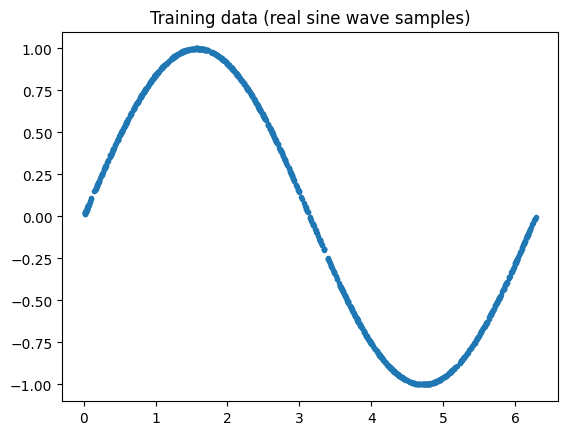

In [2]:
train_data_length = 1024
train_data = torch.zeros((train_data_length, 2))
train_data[:, 0] = 2.0 * math.pi * torch.rand(train_data_length)
train_data[:, 1] = torch.sin(train_data[:, 0])
train_labels = torch.zeros(train_data_length)
train_set = [(train_data[i], train_labels[i]) for i in range(train_data_length)]

plt.plot(train_data[:, 0], train_data[:, 1], ".")
plt.title("Training data (real sine wave samples)")
plt.show()

## Creating the Data Loader

In [3]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True
)

## Implementing the Discriminator

In [4]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        output = self.model(x)
        return output


discriminator = Discriminator()

## Implementing the Generator

- Two hidden layers (16 and 32 neurons), ReLU activations, no dropout. Output layer maps back to 2D with no activation, since the output is a coordinate, not a probability.

In [5]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
        )

    def forward(self, x):
        output = self.model(x)
        return output


generator = Generator()

## Defining Training Hyperparameters

In [6]:
lr = 0.001
num_epochs = 2000
loss_function = nn.BCELoss()

## Defining the Optimisers

In [7]:
optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

## Training Loop

In [8]:
d_losses = []
g_losses = []

for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(train_loader):
        # Data for training the discriminator.
        real_samples_labels = torch.ones((batch_size, 1))
        latent_space_samples = torch.randn((batch_size, 2))
        generated_samples = generator(latent_space_samples)
        generated_samples_labels = torch.zeros((batch_size, 1))
        all_samples = torch.cat((real_samples, generated_samples))
        all_samples_labels = torch.cat(
            (real_samples_labels, generated_samples_labels)
        )

        # Training the discriminator.
        discriminator.zero_grad()
        output_discriminator = discriminator(all_samples)
        loss_discriminator = loss_function(output_discriminator, all_samples_labels)
        loss_discriminator.backward()
        optimizer_discriminator.step()

        # Data for training the generator.
        latent_space_samples = torch.randn((batch_size, 2))

        # Training the generator.
        generator.zero_grad()
        generated_samples = generator(latent_space_samples)
        output_discriminator_generated = discriminator(generated_samples)
        loss_generator = loss_function(
            output_discriminator_generated, real_samples_labels
        )
        loss_generator.backward()
        optimizer_generator.step()

        # Print loss at various training stages.
        print_epoch_num = 100
        if epoch % print_epoch_num == 0 and n == batch_size - 1:
            print(f"Epoch: {epoch} Loss D.: {loss_discriminator}")
            print(f"Epoch: {epoch} Loss G.: {loss_generator}")

    d_losses.append(loss_discriminator.item())
    g_losses.append(loss_generator.item())

Epoch: 0 Loss D.: 0.10651858150959015
Epoch: 0 Loss G.: 2.6915292739868164
Epoch: 100 Loss D.: 0.6771022081375122
Epoch: 100 Loss G.: 0.7336205840110779
Epoch: 200 Loss D.: 0.6455041170120239
Epoch: 200 Loss G.: 0.883645236492157
Epoch: 300 Loss D.: 0.7510595917701721
Epoch: 300 Loss G.: 0.6410450339317322
Epoch: 400 Loss D.: 0.6402899622917175
Epoch: 400 Loss G.: 0.8643763065338135
Epoch: 500 Loss D.: 0.6194202303886414
Epoch: 500 Loss G.: 1.0063339471817017
Epoch: 600 Loss D.: 0.6766213178634644
Epoch: 600 Loss G.: 0.7338934540748596
Epoch: 700 Loss D.: 0.7163495421409607
Epoch: 700 Loss G.: 0.7215312123298645
Epoch: 800 Loss D.: 0.7765070796012878
Epoch: 800 Loss G.: 0.883323073387146
Epoch: 900 Loss D.: 0.5988984704017639
Epoch: 900 Loss G.: 1.0034375190734863
Epoch: 1000 Loss D.: 0.6808976531028748
Epoch: 1000 Loss G.: 0.6545848250389099
Epoch: 1100 Loss D.: 0.6375536918640137
Epoch: 1100 Loss G.: 0.8529494404792786
Epoch: 1200 Loss D.: 0.6668440103530884
Epoch: 1200 Loss G.: 0.66

## Plotting the Training Losses

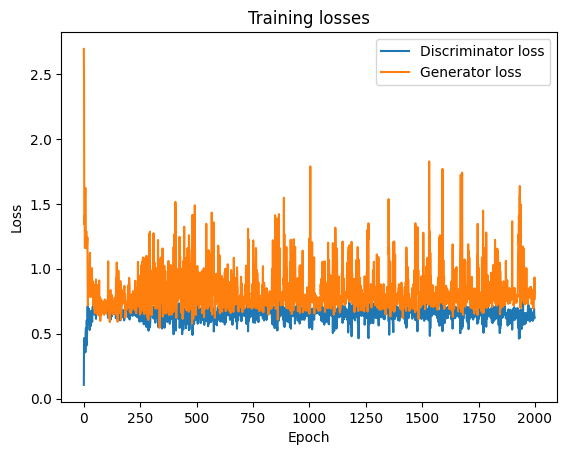

In [9]:
plt.plot(d_losses, label="Discriminator loss")
plt.plot(g_losses, label="Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training losses")
plt.show()

## Testing the GAN: Real vs Generated Samples

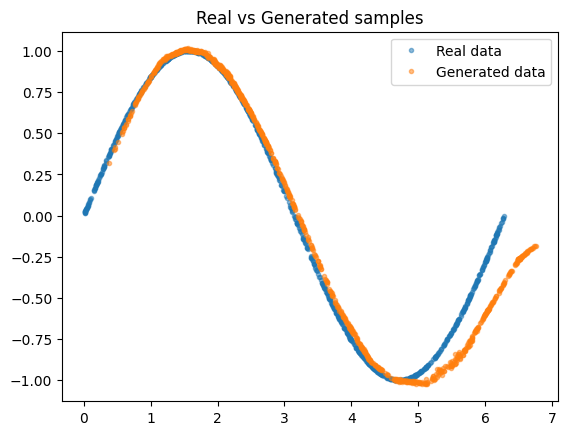

In [10]:
latent_space_samples = torch.randn(1000, 2)
generated_samples = generator(latent_space_samples)
generated_samples_numpy = generated_samples.detach().numpy()

plt.plot(train_data[:, 0], train_data[:, 1], ".", label="Real data", alpha=0.5)
plt.plot(
    generated_samples_numpy[:, 0],
    generated_samples_numpy[:, 1],
    ".",
    label="Generated data",
    alpha=0.5,
)
plt.legend()
plt.title("Real vs Generated samples")
plt.show()

## Seed Sensitivity Check
- Re-running the same GAN with a different random seed to observe how initialization affects the final result.

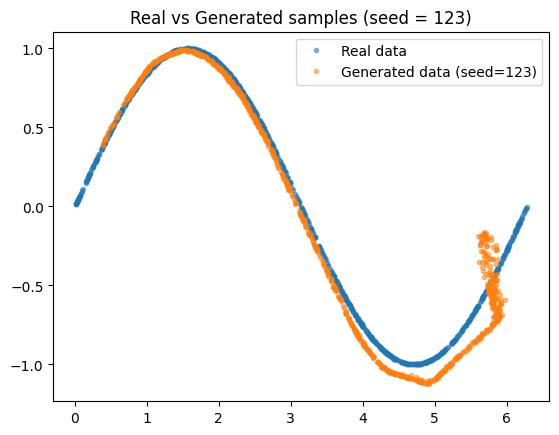

In [11]:
torch.manual_seed(123)  # different seed

# Re-instantiate
discriminator = Discriminator()
generator = Generator()
optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(train_loader):
        real_samples_labels = torch.ones((batch_size, 1))
        latent_space_samples = torch.randn((batch_size, 2))
        generated_samples = generator(latent_space_samples)
        generated_samples_labels = torch.zeros((batch_size, 1))
        all_samples = torch.cat((real_samples, generated_samples))
        all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))

        discriminator.zero_grad()
        output_discriminator = discriminator(all_samples)
        loss_discriminator = loss_function(output_discriminator, all_samples_labels)
        loss_discriminator.backward()
        optimizer_discriminator.step()

        latent_space_samples = torch.randn((batch_size, 2))
        generator.zero_grad()
        generated_samples = generator(latent_space_samples)
        output_discriminator_generated = discriminator(generated_samples)
        loss_generator = loss_function(output_discriminator_generated, real_samples_labels)
        loss_generator.backward()
        optimizer_generator.step()

latent_space_samples = torch.randn(1000, 2)
generated_samples = generator(latent_space_samples)
generated_samples_numpy = generated_samples.detach().numpy()

plt.plot(train_data[:, 0], train_data[:, 1], ".", label="Real data", alpha=0.5)
plt.plot(generated_samples_numpy[:, 0], generated_samples_numpy[:, 1], ".", label="Generated data (seed=123)", alpha=0.5)
plt.legend()
plt.title("Real vs Generated samples (seed = 123)")
plt.show()

## Observations

In both training runs (seed = 42 and seed = 123), the generator successfully learned the overall shape of the sine wave over the domain [0, 2π]. The generated samples clearly follow the characteristic "hump up, hump down" pattern of sin(x), rather than collapsing into a blob or scattering randomly — confirming that the adversarial training process converged to a meaningful solution rather than failing outright.

The fit is not uniform across the domain, however. The generated points diverge most from the real data near the trough of the curve (x ≈ 4.5–5) and at the domain boundaries (x near 0 and x near 2π), where the scatter increases and point density becomes less consistent. By contrast, along the smoother rising and falling sections in the middle of the curve, the generated points closely track the real distribution. This is likely a limitation of the generator's small MLP architecture (two hidden layers of 16 and 32 neurons) combined with the difficulty of representing sharp curvature and boundary discontinuities with a low-capacity network.

Comparing the two seeds directly, overall output quality was broadly consistent: both runs converged to a recognizable sine shape with the same pattern of strengths and weaknesses (tight fit in the middle, more scatter near the trough and edges). Neither seed produced a dramatically better or worse result — the differences were limited to minor variation in the exact scatter pattern and placement of noisier points, rather than a qualitative difference in training success. This suggests the model architecture and training setup are reasonably robust to initialization, at least for this simple 2D task.

This seed sensitivity is expected, since `torch.manual_seed()` controls both the random initialization of the discriminator and generator weights and the random latent noise sampled during training. Different seeds therefore send the adversarial optimization down slightly different trajectories, which explains why the two runs are structurally similar but not identical.

# Part 1, Task 2: Modelling a New 2D Distribution — Spiral

### Generating the Training Data (2D Spiral)

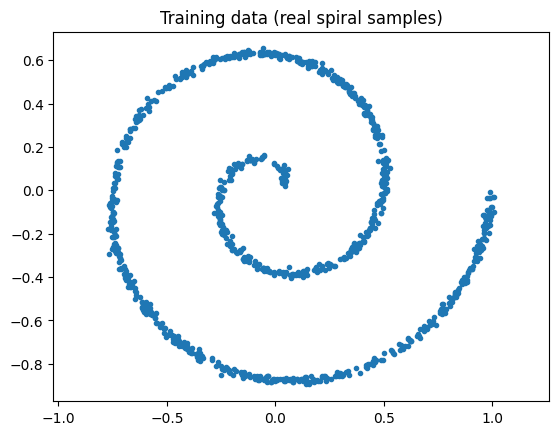

In [12]:
torch.manual_seed(42)

spiral_data_length = 1024
theta = torch.sqrt(torch.rand(spiral_data_length)) * 4 * math.pi  # angle, sqrt for even spacing
r = theta  # radius grows with angle

spiral_data = torch.zeros((spiral_data_length, 2))
spiral_data[:, 0] = r * torch.cos(theta)
spiral_data[:, 1] = r * torch.sin(theta)

# Normalise to a similar scale as the sine wave data (roughly -1 to 1),
# since the GAN architecture and learning rate were tuned for that scale.
spiral_data = spiral_data / spiral_data.abs().max()

# Add a small amount of noise so the spiral isn't a perfectly thin line
spiral_data += 0.01 * torch.randn_like(spiral_data)

spiral_labels = torch.zeros(spiral_data_length)
spiral_set = [(spiral_data[i], spiral_labels[i]) for i in range(spiral_data_length)]

plt.plot(spiral_data[:, 0], spiral_data[:, 1], ".")
plt.title("Training data (real spiral samples)")
plt.axis("equal")
plt.show()

## Creating the Data Loader

In [13]:
spiral_loader = torch.utils.data.DataLoader(
    spiral_set, batch_size=batch_size, shuffle=True
)

## Re-using the Discriminator and Generator Architectures

- Same architecture as Task 1, re-instantiated so training starts fresh for the new distribution.

In [14]:
discriminator_spiral = Discriminator()
generator_spiral = Generator()

optimizer_discriminator_spiral = torch.optim.Adam(discriminator_spiral.parameters(), lr=lr)
optimizer_generator_spiral = torch.optim.Adam(generator_spiral.parameters(), lr=lr)

## Training Loop

In [15]:
d_losses_spiral = []
g_losses_spiral = []

for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(spiral_loader):
        real_samples_labels = torch.ones((batch_size, 1))
        latent_space_samples = torch.randn((batch_size, 2))
        generated_samples = generator_spiral(latent_space_samples)
        generated_samples_labels = torch.zeros((batch_size, 1))
        all_samples = torch.cat((real_samples, generated_samples))
        all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))

        discriminator_spiral.zero_grad()
        output_discriminator = discriminator_spiral(all_samples)
        loss_discriminator = loss_function(output_discriminator, all_samples_labels)
        loss_discriminator.backward()
        optimizer_discriminator_spiral.step()

        latent_space_samples = torch.randn((batch_size, 2))
        generator_spiral.zero_grad()
        generated_samples = generator_spiral(latent_space_samples)
        output_discriminator_generated = discriminator_spiral(generated_samples)
        loss_generator = loss_function(output_discriminator_generated, real_samples_labels)
        loss_generator.backward()
        optimizer_generator_spiral.step()

        if epoch % 100 == 0 and n == batch_size - 1:
            print(f"Epoch: {epoch} Loss D.: {loss_discriminator}")
            print(f"Epoch: {epoch} Loss G.: {loss_generator}")

    d_losses_spiral.append(loss_discriminator.item())
    g_losses_spiral.append(loss_generator.item())

Epoch: 0 Loss D.: 0.4785008430480957
Epoch: 0 Loss G.: 0.9692978262901306
Epoch: 100 Loss D.: 0.6157582402229309
Epoch: 100 Loss G.: 1.2021414041519165
Epoch: 200 Loss D.: 0.5714656710624695
Epoch: 200 Loss G.: 1.046569585800171
Epoch: 300 Loss D.: 0.6624008417129517
Epoch: 300 Loss G.: 0.8224385976791382
Epoch: 400 Loss D.: 0.6237310767173767
Epoch: 400 Loss G.: 0.7563780546188354
Epoch: 500 Loss D.: 0.6697584390640259
Epoch: 500 Loss G.: 0.9200080633163452
Epoch: 600 Loss D.: 0.6199878454208374
Epoch: 600 Loss G.: 0.8738812208175659
Epoch: 700 Loss D.: 0.5853430032730103
Epoch: 700 Loss G.: 0.9792587161064148
Epoch: 800 Loss D.: 0.6655817627906799
Epoch: 800 Loss G.: 1.0817954540252686
Epoch: 900 Loss D.: 0.6414657235145569
Epoch: 900 Loss G.: 0.7216455936431885
Epoch: 1000 Loss D.: 0.6252483129501343
Epoch: 1000 Loss G.: 0.8123854994773865
Epoch: 1100 Loss D.: 0.6746340990066528
Epoch: 1100 Loss G.: 0.7575750350952148
Epoch: 1200 Loss D.: 0.6485312581062317
Epoch: 1200 Loss G.: 0.80

## Plotting the Training Losses

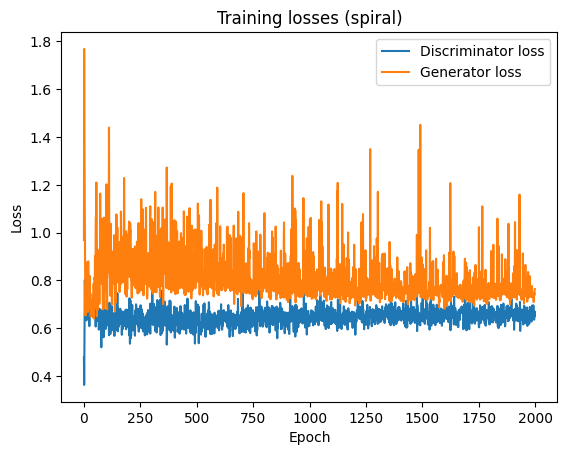

In [16]:
plt.plot(d_losses_spiral, label="Discriminator loss")
plt.plot(g_losses_spiral, label="Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training losses (spiral)")
plt.show()

## Testing the GAN: Real vs Generated Samples

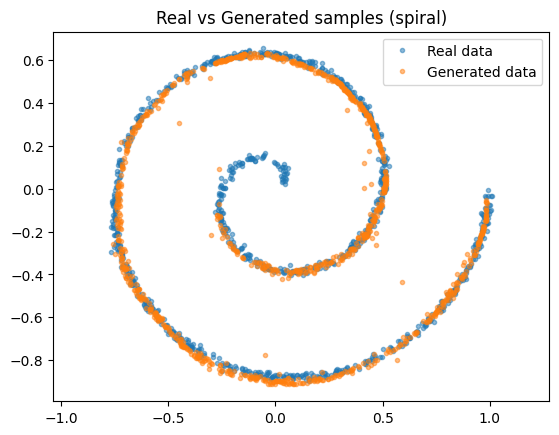

In [17]:
latent_space_samples = torch.randn(1000, 2)
generated_samples = generator_spiral(latent_space_samples)
generated_samples_numpy = generated_samples.detach().numpy()

plt.plot(spiral_data[:, 0], spiral_data[:, 1], ".", label="Real data", alpha=0.5)
plt.plot(generated_samples_numpy[:, 0], generated_samples_numpy[:, 1], ".", label="Generated data", alpha=0.5)
plt.legend()
plt.title("Real vs Generated samples (spiral)")
plt.axis("equal")
plt.show()

## Observations

The generator's performance on the spiral was noticeably weaker than on the sine wave, and importantly, the weakness was not uniform across the shape.

In the outer part of the spiral, where the loops are widely spaced and curvature is gentle, the generated (orange) points loosely but reasonably follow the real (blue) arm's path. Moving inward toward the tightly-wound core, however, the fit breaks down substantially: rather than tracking the successive individual windings, the generated points collapse into a dense, undifferentiated blob near the origin. The generator fails to resolve the closely-spaced inner loops, effectively smearing several separate arms of the spiral together.

This uneven performance is consistent with the underlying difficulty of the task. The sine wave used in Task 1 is a single-valued function — for each x, there is exactly one y — and the generator, a simple two-hidden-layer MLP (16 and 32 units) with no positional or geometric inductive bias, was able to represent this reasonably well across nearly the full domain, with only mild scatter near the trough and boundaries. The spiral, by contrast, is fundamentally harder: because it winds around the origin multiple times, nearby (x, y) locations in the plane can correspond to very different points along the underlying 1D curve depending on how many revolutions have occurred. This makes the spiral a multi-valued, self-overlapping relationship in 2D space rather than a simple function, and a small unconditioned MLP mapping from a 2D Gaussian latent space struggles to preserve this fine local structure — particularly where the radius (and hence the spacing between windings) becomes small.

Overall, this comparison illustrates a general limitation of small, fully-connected GAN architectures: they can capture the coarse, global shape of a target distribution but may fail to resolve fine local structure, especially in regions of high curvature or where the target manifold is geometrically complex. This motivates the architecture modifications explored in Task 3.

# Part 1, Task 3: Modifying the GAN Architecture

To test whether generator capacity was the limiting factor identified in Task 2, this section modifies the generator architecture — increasing depth/width and switching from ReLU to LeakyReLU — and retrains on the same spiral data. The discriminator and all other training settings (learning rate, epochs, batch size) are kept identical to Task 2, so any difference in output can be attributed to the architecture change alone.

## Modified Generator: Deeper, Wider, LeakyReLU

In [18]:
class GeneratorV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 2),
        )

    def forward(self, x):
        output = self.model(x)
        return output

## Re-training on the Spiral with the Modified Generator

In [19]:
torch.manual_seed(42)

discriminator_v2 = Discriminator()          # same discriminator as before
generator_v2 = GeneratorV2()                # modified generator

optimizer_discriminator_v2 = torch.optim.Adam(discriminator_v2.parameters(), lr=lr)
optimizer_generator_v2 = torch.optim.Adam(generator_v2.parameters(), lr=lr)

d_losses_v2 = []
g_losses_v2 = []

for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(spiral_loader):
        real_samples_labels = torch.ones((batch_size, 1))
        latent_space_samples = torch.randn((batch_size, 2))
        generated_samples = generator_v2(latent_space_samples)
        generated_samples_labels = torch.zeros((batch_size, 1))
        all_samples = torch.cat((real_samples, generated_samples))
        all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))

        discriminator_v2.zero_grad()
        output_discriminator = discriminator_v2(all_samples)
        loss_discriminator = loss_function(output_discriminator, all_samples_labels)
        loss_discriminator.backward()
        optimizer_discriminator_v2.step()

        latent_space_samples = torch.randn((batch_size, 2))
        generator_v2.zero_grad()
        generated_samples = generator_v2(latent_space_samples)
        output_discriminator_generated = discriminator_v2(generated_samples)
        loss_generator = loss_function(output_discriminator_generated, real_samples_labels)
        loss_generator.backward()
        optimizer_generator_v2.step()

        if epoch % 100 == 0 and n == batch_size - 1:
            print(f"Epoch: {epoch} Loss D.: {loss_discriminator}")
            print(f"Epoch: {epoch} Loss G.: {loss_generator}")

    d_losses_v2.append(loss_discriminator.item())
    g_losses_v2.append(loss_generator.item())

Epoch: 0 Loss D.: 0.5009289383888245
Epoch: 0 Loss G.: 1.1487131118774414
Epoch: 100 Loss D.: 0.6556286811828613
Epoch: 100 Loss G.: 0.7170259952545166
Epoch: 200 Loss D.: 0.6727774739265442
Epoch: 200 Loss G.: 0.7372761964797974
Epoch: 300 Loss D.: 0.6393502950668335
Epoch: 300 Loss G.: 0.8111029267311096
Epoch: 400 Loss D.: 0.653306782245636
Epoch: 400 Loss G.: 0.8119286298751831
Epoch: 500 Loss D.: 0.6732551455497742
Epoch: 500 Loss G.: 0.7238253951072693
Epoch: 600 Loss D.: 0.6212663054466248
Epoch: 600 Loss G.: 0.7734265327453613
Epoch: 700 Loss D.: 0.6841540336608887
Epoch: 700 Loss G.: 0.7286226749420166
Epoch: 800 Loss D.: 0.6553435325622559
Epoch: 800 Loss G.: 0.7293186783790588
Epoch: 900 Loss D.: 0.6572965383529663
Epoch: 900 Loss G.: 0.7107842564582825
Epoch: 1000 Loss D.: 0.6534726023674011
Epoch: 1000 Loss G.: 0.7426012754440308
Epoch: 1100 Loss D.: 0.6923235058784485
Epoch: 1100 Loss G.: 0.9932171702384949
Epoch: 1200 Loss D.: 0.6458305716514587
Epoch: 1200 Loss G.: 1.17

## Plotting the Training Losses (Modified Generator)

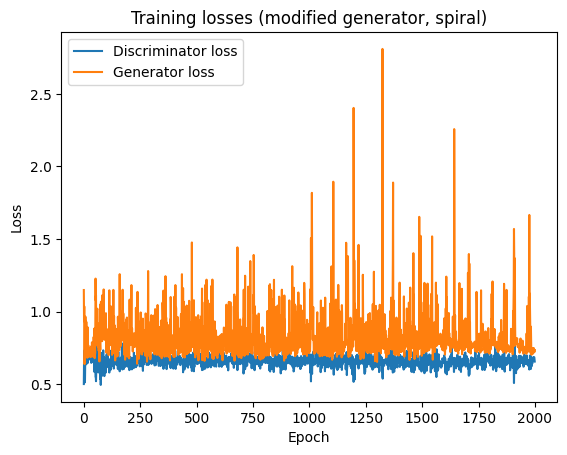

In [20]:
plt.plot(d_losses_v2, label="Discriminator loss")
plt.plot(g_losses_v2, label="Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training losses (modified generator, spiral)")
plt.show()

## Visual Comparison: Original Generator vs Modified Generator

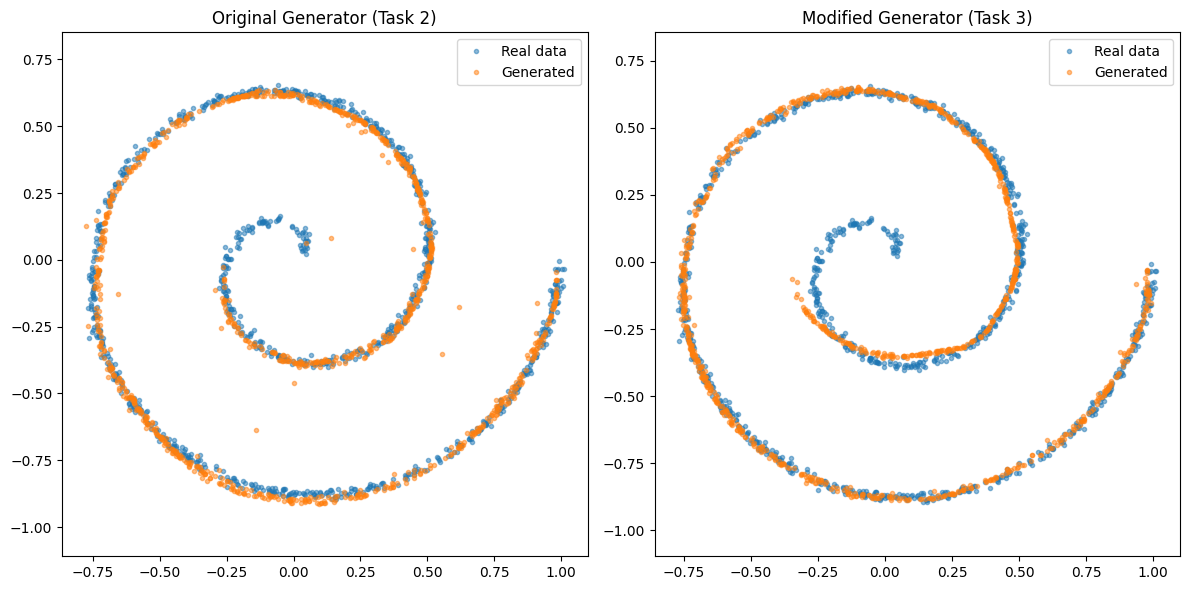

In [21]:
# Generate samples from the modified generator
latent_space_samples = torch.randn(1000, 2)
generated_samples_v2 = generator_v2(latent_space_samples)
generated_samples_v2_numpy = generated_samples_v2.detach().numpy()

# Regenerate samples from the original Task 2 generator for a fair side-by-side
latent_space_samples_orig = torch.randn(1000, 2)
generated_samples_orig = generator_spiral(latent_space_samples_orig)
generated_samples_orig_numpy = generated_samples_orig.detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].plot(spiral_data[:, 0], spiral_data[:, 1], ".", label="Real data", alpha=0.5)
axes[0].plot(generated_samples_orig_numpy[:, 0], generated_samples_orig_numpy[:, 1], ".", label="Generated", alpha=0.5)
axes[0].set_title("Original Generator (Task 2)")
axes[0].legend()
axes[0].axis("equal")

axes[1].plot(spiral_data[:, 0], spiral_data[:, 1], ".", label="Real data", alpha=0.5)
axes[1].plot(generated_samples_v2_numpy[:, 0], generated_samples_v2_numpy[:, 1], ".", label="Generated", alpha=0.5)
axes[1].set_title("Modified Generator (Task 3)")
axes[1].legend()
axes[1].axis("equal")

plt.tight_layout()
plt.show()

## Quantitative Comparison: Nearest-Neighbour Distance by Radius

To go beyond a visual comparison, we quantify how closely each generator's samples match the real spiral data. For each generated point, we compute the distance to its nearest real data point. We then bin these distances by radius from the spiral's centre (splitting the spiral into four radius bands, from innermost to outermost), to check whether the fit is uneven across the tightly-wound core versus the looser outer arms — the specific weakness identified in Task 2.

In [22]:
import numpy as np

def nearest_neighbour_distances(generated_np, real_tensor):
    """For each generated point, find the distance to its nearest real data point."""
    real_np = real_tensor.detach().numpy()
    # pairwise distances: (num_generated, num_real)
    dists = np.sqrt(((generated_np[:, None, :] - real_np[None, :, :]) ** 2).sum(axis=2))
    nearest_dist = dists.min(axis=1)
    return nearest_dist

def radius_from_center(points_np):
    return np.sqrt((points_np ** 2).sum(axis=1))

# Real data radii, used to define bin edges (quartiles of the real spiral's radius)
real_radii = radius_from_center(spiral_data.numpy())
bin_edges = np.quantile(real_radii, [0, 0.25, 0.5, 0.75, 1.0])
bin_labels = ["Innermost", "Inner-mid", "Outer-mid", "Outermost"]

on_curve_threshold = 0.03  # distance (in data units) counted as "close to the real curve"

def summarise_by_radius(generated_np, real_tensor, label):
    nn_dist = nearest_neighbour_distances(generated_np, real_tensor)
    gen_radii = radius_from_center(generated_np)

    print(f"--- {label} ---")
    for i in range(4):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (gen_radii >= lo) & (gen_radii <= hi)
        n_points = mask.sum()
        if n_points == 0:
            print(f"{bin_labels[i]:>12}: 0 generated points fall in this radius band")
            continue
        mean_dist = nn_dist[mask].mean()
        on_curve_frac = (nn_dist[mask] < on_curve_threshold).mean()
        print(f"{bin_labels[i]:>12}: n={n_points:4d}  mean dist={mean_dist:.4f}  on-curve frac={on_curve_frac:.2%}")

    overall_mean = nn_dist.mean()
    overall_frac = (nn_dist < on_curve_threshold).mean()
    print(f"{'Overall':>12}: mean dist={overall_mean:.4f}  on-curve frac={overall_frac:.2%}")
    print()

summarise_by_radius(generated_samples_orig_numpy, spiral_data, "Original Generator (Task 2)")
summarise_by_radius(generated_samples_v2_numpy, spiral_data, "Modified Generator (Task 3)")

--- Original Generator (Task 2) ---
   Innermost: n= 185  mean dist=0.0094  on-curve frac=97.84%
   Inner-mid: n= 311  mean dist=0.0106  on-curve frac=97.43%
   Outer-mid: n= 235  mean dist=0.0095  on-curve frac=98.30%
   Outermost: n= 269  mean dist=0.0128  on-curve frac=96.65%
     Overall: mean dist=0.0107  on-curve frac=97.50%

--- Modified Generator (Task 3) ---
   Innermost: n= 211  mean dist=0.0149  on-curve frac=91.47%
   Inner-mid: n= 235  mean dist=0.0087  on-curve frac=100.00%
   Outer-mid: n= 326  mean dist=0.0088  on-curve frac=100.00%
   Outermost: n= 228  mean dist=0.0082  on-curve frac=99.12%
     Overall: mean dist=0.0099  on-curve frac=98.00%



## Observations

Quantitatively, both generators score well on nearest-neighbour distance: the original generator achieved an overall mean distance of 0.0107 with 97.5% of points falling within the on-curve threshold, while the modified generator achieved 0.0099 and 98.0% — a small, consistent improvement across every radius band except the innermost, where the modified generator's on-curve fraction actually dropped slightly (91.5% vs 97.8%).

However, these numbers understate the visual failure identified in Task 2. Nearest-neighbour distance only measures whether a generated point lies close to *some* real data point, not whether it lies on the *correct* winding of the spiral. Because the spiral's inner loops pass close to one another in physical space, a generated point can score a low distance and a "true" on-curve classification while still being placed on the wrong winding — exactly the blobbing failure visible in the scatter plots. This is a genuine limitation of point-wise distance metrics for self-overlapping geometries like a spiral: a metric that ignores the manifold's winding structure will systematically overstate quality in densely-packed regions.

Taking the visual and quantitative results together, the honest conclusion is: the modified generator (deeper, LeakyReLU) produced a small, real improvement in overall curve-tracking tightness, but did not resolve the underlying failure to distinguish closely-spaced inner windings — and a naive distance-based metric would have masked this problem entirely. A more appropriate evaluation for this kind of structured 2D distribution would need to account for position *along* the curve (e.g. matching generated points to their nearest point in arc-length, not just Euclidean space), which is beyond the scope of this task but worth noting as a limitation of the evaluation approach used here.